<div style="margin-bottom: 120px;">
    <div style="float:left;">
        <br/>
        <img src="img/udc.png" width="300"/>
    </div>
</div>

<h1 style="color: #d60e8c; text-align:center;">Clasificación con kNN sin balanceo de datos</h1>

<a name="intro"></a>
<h1 style="color: #d60e8c;">Importamos las librerías</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import time as clocktime

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, ShuffleSplit, KFold, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV


<a name="dataset"></a>
<h1 style="color: #d60e8c;">Lectura del conjunto de datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = '/content/drive/MyDrive/Notebooks/puntos_pose/puntos_imgs_sin_v.csv'
#path = 'puntos_imgs_sin_v.csv'

In [4]:
df = pd.read_csv(path)
df.head()

,name,front_left_paw_x,front_left_paw_y,front_left_knee_x,front_left_knee_y,front_left_elbow_x,front_left_elbow_y,rear_left_paw_x,rear_left_paw_y,rear_left_knee_x,...,right_ear_tip_y,left_eye_x,left_eye_y,right_eye_x,right_eye_y,withers_x,withers_y,throat_x,throat_y,class
0,n02085620_10074.jpg,0.69520,0.96500,0.66066,0.82400,0.66817,0.67700,0.00000,0.00000,0.0,...,0.06820,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,n02085620_10131.jpg,0.00000,0.00000,0.73502,0.90034,0.73165,0.64646,0.00000,0.00000,0.0,...,0.12733,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,n02085620_1073.jpg,0.00000,0.00000,0.58744,0.96600,0.68792,0.77467,0.00000,0.00000,0.0,...,0.05588,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,n02085620_10976.jpg,0.69876,0.85744,0.63043,0.80096,0.64286,0.67975,0.69876,0.77376,0.0,...,0.24455,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,n02085620_11140.jpg,0.79100,0.56133,0.71000,0.55333,0.62600,0.47867,0.00000,0.00000,0.0,...,0.15180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [5]:
df.shape

(6125, 50)

In [6]:
df['class'].value_counts()

,count
class,
1,3371
0,1454
2,1300


In [7]:
df['class'] = df['class'].map({0: 0, 1: 1, 2: 0})
df['class'].value_counts()

,count
class,
1,3371
0,2754


In [8]:
df['class'].value_counts()

,count
class,
1,3371
0,2754


<a name="division"></a>
<h1 style="color: #d60e8c;">Selección de atributos de entrada y salida</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [9]:
# 30 seleccionadas
feature_df = df[['front_left_paw_x', 'front_left_paw_y', 'front_left_knee_x',
       'front_left_knee_y', 'front_left_elbow_x', 'front_left_elbow_y',
       'rear_left_paw_x', 'rear_left_paw_y', 'rear_left_knee_x',
       'rear_left_knee_y', 'rear_left_elbow_x', 'rear_left_elbow_y',
       'front_right_paw_x', 'front_right_paw_y', 'front_right_knee_x',
       'front_right_knee_y', 'front_right_elbow_x', 'front_right_elbow_y',
       'rear_right_paw_x', 'rear_right_paw_y', 'rear_right_knee_x',
       'rear_right_knee_y', 'rear_right_elbow_x', 'rear_right_elbow_y',
       'tail_start_x', 'tail_start_y', 'withers_x', 'withers_y', 'throat_x', 'throat_y']]
X_orig = np.asarray(feature_df)

In [10]:
y = np.asarray(df[df.columns[len(df.columns)-1]])

<a name="train_test"></a>
<h1 style="color: #d60e8c;">División en datos de entrenamiento y prueba</h1>
<hr style="border: 0.5px solid #d60e8c;">
El siguiente código, utiliza el 80% del conjunto de datos para entrenar el modelo y el 20% para test.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size=0.2, random_state = 4, stratify=y)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (4900, 30) (4900,)
Test set: (1225, 30) (1225,)


<a name="scale"></a>
<h1 style="color: #d60e8c;">Escalado de los datos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [12]:
scaler = preprocessing.StandardScaler()
scaler.fit(X_train) # fit realiza los cálculos y los almacena

X_train = scaler.transform(X_train) # aplica los cálculos sobre el conjunto de datos de entrada para escalarlos
X_test = scaler.transform(X_test)

<a name="scale"></a>
<h1 style="color: #d60e8c;">Búsqueda de los mejore hiperparámetros con GridSearchCV</h1>
<hr style="border: 0.5px solid #d60e8c;">


In [14]:
num_splits = 3

In [15]:
parameters = {'n_neighbors': range(1,101)}

model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, cv=num_splits, n_jobs=-1, refit=False)
clf.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 101)}, refit=False)

In [16]:
clf.cv_results_

{'mean_fit_time': array([0.00228707, 0.00219417, 0.0017914 , 0.00120083, 0.00125853,
        0.00111802, 0.00140047, 0.00143814, 0.0016249 , 0.00251333,
        0.00230026, 0.00157881, 0.0014743 , 0.00157348, 0.00237719,
        0.00148376, 0.00144005, 0.00124629, 0.00146818, 0.00112534,
        0.00161171, 0.00102297, 0.00110682, 0.00107304, 0.00129294,
        0.00118717, 0.00271821, 0.00112653, 0.00118327, 0.00119058,
        0.00119257, 0.0009946 , 0.00107384, 0.00119011, 0.00132084,
        0.00144831, 0.00138466, 0.0015134 , 0.00146365, 0.00131599,
        0.00149488, 0.00143083, 0.00136161, 0.0013365 , 0.00132306,
        0.0013938 , 0.00136145, 0.00142868, 0.00128285, 0.00131281,
        0.00215816, 0.00223168, 0.00128245, 0.0013593 , 0.00132068,
        0.00215332, 0.00175389, 0.0024778 , 0.00292905, 0.00117326,
        0.00550747, 0.00261513, 0.00157483, 0.00230575, 0.00139308,
        0.00114608, 0.00115577, 0.00124558, 0.00133872, 0.00140476,
        0.00234858, 0.00126632,

In [17]:
clf.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_n_neighbors', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [18]:
import pandas as pd

results_df = pd.DataFrame(clf.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
7,0.001438,0.000265,0.045772,0.001791,8,{'n_neighbors': 8},0.791310,0.801592,0.763625,0.785509,0.016033,1
5,0.001118,0.000084,0.040564,0.003309,6,{'n_neighbors': 6},0.790698,0.797918,0.762400,0.783672,0.015327,2
3,0.001201,0.000039,0.039538,0.001337,4,{'n_neighbors': 4},0.787638,0.795468,0.766075,0.783060,0.012429,3
11,0.001579,0.000033,0.044903,0.000592,12,{'n_neighbors': 12},0.780294,0.792407,0.767912,0.780204,0.010000,4
13,0.001573,0.000083,0.048196,0.004184,14,{'n_neighbors': 14},0.783966,0.785671,0.767299,0.778979,0.008288,5


In [19]:

best_models = results_df[results_df["rank_test_score"]<=5]
best_models.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
7,0.001438,0.000265,0.045772,0.001791,8,{'n_neighbors': 8},0.791310,0.801592,0.763625,0.785509,0.016033,1
5,0.001118,0.000084,0.040564,0.003309,6,{'n_neighbors': 6},0.790698,0.797918,0.762400,0.783672,0.015327,2
3,0.001201,0.000039,0.039538,0.001337,4,{'n_neighbors': 4},0.787638,0.795468,0.766075,0.783060,0.012429,3
11,0.001579,0.000033,0.044903,0.000592,12,{'n_neighbors': 12},0.780294,0.792407,0.767912,0.780204,0.010000,4
13,0.001573,0.000083,0.048196,0.004184,14,{'n_neighbors': 14},0.783966,0.785671,0.767299,0.778979,0.008288,5


In [20]:

best_models[["rank_test_score", "mean_test_score", "std_test_score", "params"]]

,rank_test_score,mean_test_score,std_test_score,params
7,1,0.785509,0.016033,{'n_neighbors': 8}
5,2,0.783672,0.015327,{'n_neighbors': 6}
3,3,0.783060,0.012429,{'n_neighbors': 4}
11,4,0.780204,0.010000,{'n_neighbors': 12}
13,5,0.778979,0.008288,{'n_neighbors': 14}


<a name="crossval"></a>
<h1 style="color: #d60e8c;">Validación cruzada con los mejores modelos</h1>
<hr style="border: 0.5px solid #d60e8c;">

In [21]:
kf_sh = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=0) 

In [22]:
test_sets = []
for train_index, test_index in kf_sh.split(X_train, y_train):
    X_train_split, X_test_split = X_train[train_index], X_train[test_index]
    y_train_split, y_test_split = y_train[train_index], y_train[test_index]
    test_sets.append((X_test_split,y_test_split))

In [23]:

results = {}
for model_conf in best_models["params"]:
    model = KNeighborsClassifier(n_neighbors = model_conf['n_neighbors'])
             
    res_cv_sh = cross_validate(model,X_train,y_train,cv=kf_sh, return_estimator=True, n_jobs=-1)

    model_name = f'kNN - k: {model_conf['n_neighbors']}'
    print(model_name)
    results[model_name] = res_cv_sh


kNN - k: 8
kNN - k: 6
kNN - k: 4
kNN - k: 12
kNN - k: 14


In [24]:

conf_matrix_list = []
labels = ['0','1'] # En el diccionario las claves de las clases son string


print("\n---------------------------------------------")
print(" Exactitud, precisión y sensibilidad media")
print("---------------------------------------------\n")

print("Modelo                         ", end='')    
print("Exactitud    ", end='')
for label in labels:
    print(f"R({label})      ", end='')
for label in labels:
    print(f"P({label})      ", end='')
    
print("\n-------------------------------------------------------------------------------")

for name, res_cv_sh in results.items():
    estimators = res_cv_sh['estimator']   
    conf_matrix = []
    clf_report = []
    for i in range(len(estimators)):
        estimator = estimators[i]
        # Hacemos la predicción con el estimador del split i sobre el conjunto de test del split i
        y_predict = estimator.predict(test_sets[i][0])
        # Valores esperados del conjunto de test del split i
        y_expected = test_sets[i][1]
        # Obtenemos la matriz de confusión y la añadimos a la lista
        conf_matrix.append(confusion_matrix(y_expected, y_predict))
        # Añadimos el classification_report del estimador actual a la lista
        clf_report.append(classification_report(y_expected, y_predict, output_dict=True, zero_division=1))
        #print(classification_report(y_expected, y_predict))

    conf_matrix_list.append((name,conf_matrix))
    
    recall = np.zeros(len(labels))
    precision = np.zeros(len(labels))
    accuracy = []
    for dic in clf_report:
        # Para cada clase, obtiene su valor de exactitud de cada split y la añade a una lista
        for label in labels:
            recall[labels.index(label)] = recall[labels.index(label)] + dic[label]['recall']
            precision[labels.index(label)] = precision[labels.index(label)] + dic[label]['precision']
        accuracy.append(dic['accuracy']) 
    # Para cada clase, calcula la media de la exactitud
    for label in labels:
        recall[labels.index(label)] = recall[labels.index(label)] / len(clf_report)
        precision[labels.index(label)] = precision[labels.index(label)] / len(clf_report)

    accuracy = np.array(accuracy) # Conversión a nparray para usar la función mean
    mean_acc = accuracy.mean()    


    print(f"{name:28}", end='')        
    print(f"{mean_acc:10.3f}", end='')    
    for label in labels:
        print(f"{recall[labels.index(label)]:10.2f}", end='')        
    for label in labels:
        print(f"{precision[labels.index(label)]:10.2f}", end='')                   
    print()



---------------------------------------------
 Exactitud, precisión y sensibilidad media
---------------------------------------------

Modelo                         Exactitud    R(0)      R(1)      P(0)      P(1)      
-------------------------------------------------------------------------------
kNN - k: 8                       0.779      0.74      0.81      0.76      0.79
kNN - k: 6                       0.780      0.76      0.79      0.75      0.80
kNN - k: 4                       0.778      0.79      0.77      0.74      0.82
kNN - k: 12                      0.777      0.72      0.82      0.77      0.78
kNN - k: 14                      0.773      0.71      0.83      0.77      0.78


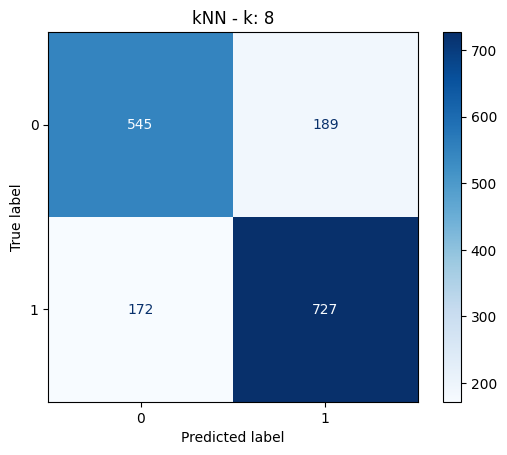

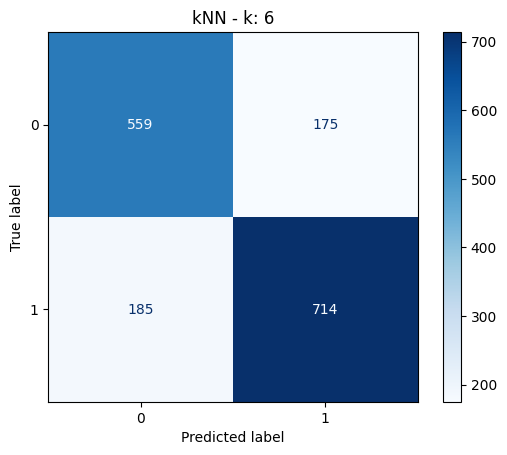

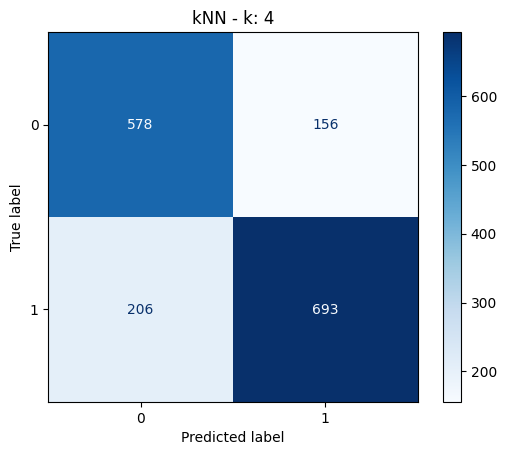

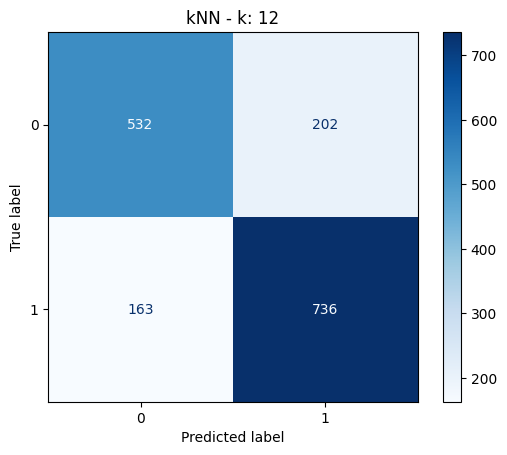

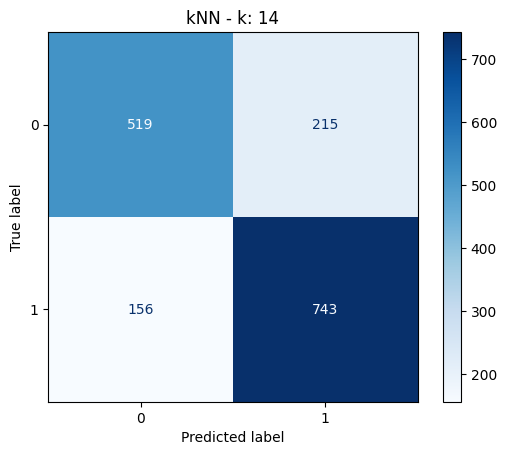

In [25]:

for name, conf_matrix in conf_matrix_list:
    avg_cm = np.zeros(conf_matrix[0].shape, dtype=int)
    for matrix in conf_matrix:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                avg_cm[i,j] +=  matrix[i,j]
    for i in range(avg_cm.shape[0]):
        for j in range(avg_cm.shape[1]):
            avg_cm[i,j] = int(round(avg_cm[i][j]/len(conf_matrix)))    

    disp = ConfusionMatrixDisplay(confusion_matrix=avg_cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(name)    
    plt.savefig(f'matrix_{name}.png',bbox_inches="tight")
    plt.show()
    plt.close()
    

<br/><br/>
<hr style="border: 0.5px solid #d60e8c;">
<div style="text-align:right;">
MASTER UNIVERSITARIO EN INGENIERÍA INDUSTRIAL
</div>